#### Time Series Forecasting

In this script, we attempt to create forecasts for average player market value

Due to the high variation in the data, we consider the historical average value as a baseline forecast and also created a more complex ARIMA model

In [1]:
#Import libraries for time series analysis 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima
from scipy.stats import boxcox
from sktime.forecasting.naive import NaiveForecaster


#### Data Prep

In [2]:
#Load club data
clubs = pd.read_csv('data/clubs.csv')

#Select relevant fields
clubs = clubs[['club_id', 'domestic_competition_id']]

#Rename domestic_competiton_id values to be more informative
clubs['league'] = clubs['domestic_competition_id'].replace({
    'TR1': 'Super Lig',
    'IT1': 'Serie A',
    'UKR1': 'Ukrainian Premier League',
    'GB1': 'Premier League',
    'FR1': 'Ligue 1',
    'PO1': 'Primeira Liga',
    'RU1': 'Russian Premier League',
    'ES1': 'La Liga',
    'L1': 'Bundesliga',
    'NL1': 'Eredivisie',
    'GR1': 'Super League Greece', 
    'BE1': 'Belgian Pro League', 
    'DK1': 'Danish Superliga', 
    'SC1': 'Scottish Premiership'
})

clubs.head()

,club_id,domestic_competition_id,league
0,10,L1,Bundesliga
1,10004,FR1,Ligue 1
2,1003,GB1,Premier League
3,1005,IT1,Serie A
4,1010,GB1,Premier League


In [3]:
#Load valuations data
valuations = pd.read_csv("data/player_valuations.csv")

#Select relevant columns (date, market value, club ID)
market_value = valuations[["date", "market_value_in_eur", "current_club_id"]].copy()

#Convert date column to datetime
market_value["date"] = pd.to_datetime(market_value["date"])

#Join market value and club data
#Only keeping market value records from players in top leagues
market_value_league = pd.merge(market_value, clubs, left_on='current_club_id', right_on='club_id')
market_value_league.head()

#Create separate data frames for big five vs. other leagues (due to value differences)
big_five_leagues = ['Premier League', 'Serie A', 'Ligue 1', 'Bundesliga', 'La Liga']
other_leagues = ['Ukrainian Premier League', 'Primeira Liga', 'Russian Premier League', 'Eredivisie', 'Super League Greece', 
                 'Belgian Pro League', 'Danish Superliga', 'Scottish Premiership']

big_five = market_value_league[market_value_league['league'].isin(big_five_leagues)][['date', 'market_value_in_eur']].copy()
other = market_value_league[market_value_league['league'].isin(other_leagues)][['date', 'market_value_in_eur']].copy()

#Aggregate mean market value by month
big_five_agg = (big_five.groupby(big_five["date"].dt.to_period('M'))["market_value_in_eur"].mean().reset_index())
other_agg = (other.groupby(other["date"].dt.to_period('M'))["market_value_in_eur"].mean().reset_index())

#Convert the period objects back to timestamps
big_five_agg['date'] = big_five_agg['date'].dt.to_timestamp()
other_agg['date'] = other_agg['date'].dt.to_timestamp()

#Set 'date' as the index and enforce Monthly Start frequency ('MS')
big_five_agg.set_index('date', inplace=True)
big_five_agg = big_five_agg.asfreq('MS')

other_agg.set_index('date', inplace=True)
other_agg = other_agg.asfreq('MS')

#Filter values only between 2005-2025 (number of records and completeness)
big_five_clean = big_five_agg[(big_five_agg.index.year >= 2005) & (big_five_agg.index.year <= 2025)].copy()
other_clean=  other_agg[(other_agg.index.year >= 2005) & (other_agg.index.year <= 2025)].copy()

#Try trimming market values to reduce variance of the time series (as done in regression modeling)
p_lower_1 = big_five_clean['market_value_in_eur'].quantile(0.05)
p_upper_1 = big_five_clean['market_value_in_eur'].quantile(0.95)

p_lower_2 = other_clean['market_value_in_eur'].quantile(0.05)
p_upper_2 = other_clean['market_value_in_eur'].quantile(0.95)

big_five_clean['market_value_capped'] = big_five_clean['market_value_in_eur'].clip(lower=p_lower_1, upper=p_upper_1)
other_clean['market_value_capped'] = other_clean['market_value_in_eur'].clip(lower=p_lower_2, upper=p_upper_2)


#### EDA

In [4]:
#Player valuation summary statistics
print("Big Five Summary Statistics:")
print(big_five_clean['market_value_capped'].describe())

print("Other Summary Statistics:")
print(other_clean['market_value_capped'].describe())

Big Five Summary Statistics:
count    2.500000e+02
mean     3.660825e+06
std      2.514793e+06
min      9.724185e+05
25%      1.859691e+06
50%      2.976122e+06
75%      4.599412e+06
max      1.027615e+07
Name: market_value_capped, dtype: float64
Other Summary Statistics:
count    2.520000e+02
mean     1.201904e+06
std      5.660266e+05
min      5.240642e+05
25%      7.759123e+05
50%      1.049652e+06
75%      1.488898e+06
max      2.512949e+06
Name: market_value_capped, dtype: float64


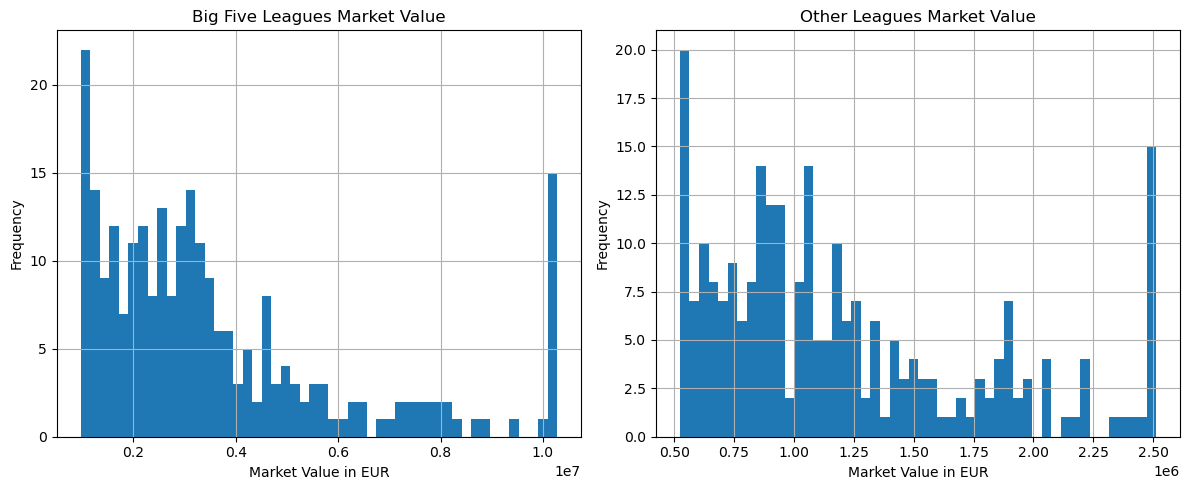

In [5]:
#Plot histograms of market values for both big five and other leagues
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

big_five_clean['market_value_capped'].hist(ax=axes[0], bins=50)
axes[0].set_title('Big Five Leagues Market Value')
axes[0].set_xlabel('Market Value in EUR')
axes[0].set_ylabel('Frequency')

other_clean['market_value_capped'].hist(ax=axes[1], bins=50)
axes[1].set_title('Other Leagues Market Value')
axes[1].set_xlabel('Market Value in EUR')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

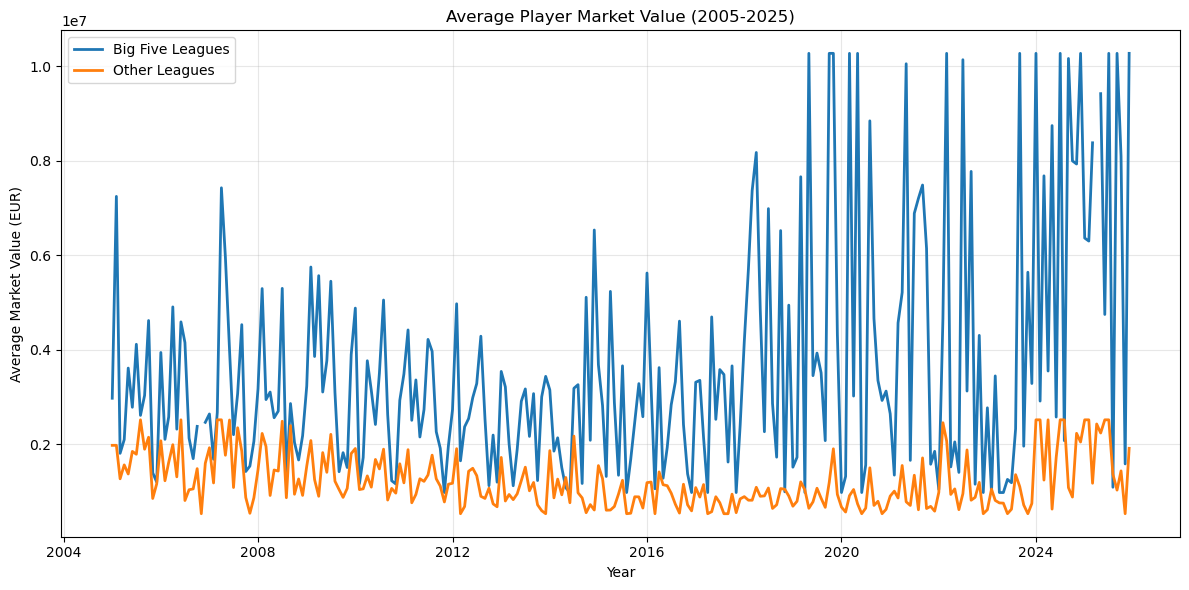

In [6]:
#Plot both time series
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(big_five_clean.index, big_five_clean['market_value_capped'], 
        label='Big Five Leagues', linewidth=2)

ax.plot(other_clean.index, other_clean['market_value_capped'], 
        label='Other Leagues', linewidth=2)

ax.set_title('Average Player Market Value (2005-2025)')
ax.set_xlabel('Year')
ax.set_ylabel('Average Market Value (EUR)')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

#### Time Series Decomposition

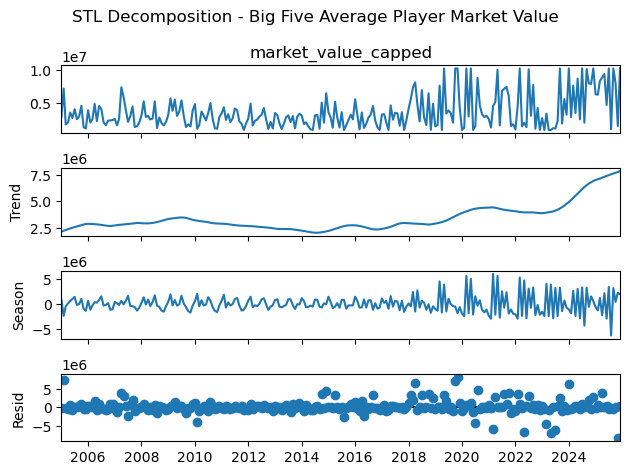

In [7]:
#Big five time series

#Fill any missing values
big_five_clean['market_value_capped'] = big_five_clean['market_value_capped'].interpolate(method='linear')

#Fit STL decomposition (period = 12 for annual data)
stl = STL(big_five_clean['market_value_capped'], period = 12, robust = True)
result = stl.fit()

# Plot the decomposition
fig = result.plot()
plt.suptitle("STL Decomposition - Big Five Average Player Market Value")
plt.tight_layout()
plt.show()

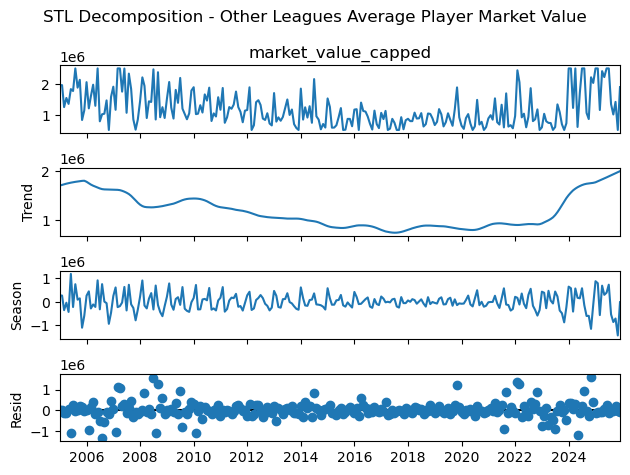

In [8]:
#Other leagues time series

#Fill any missing values
other_clean['market_value_capped'] = other_clean['market_value_capped'].interpolate(method='linear')

#Fit STL decomposition (period = 12 for annual data)
stl = STL(other_clean['market_value_capped'], period = 12, robust = True)
result = stl.fit()

# Plot the decomposition
fig = result.plot()
plt.suptitle("STL Decomposition - Other Leagues Average Player Market Value")
plt.tight_layout()
plt.show()

#### Train/test Split

In [9]:
#Before any further analysis, split data into training and test sets
big_five_train = big_five_clean[big_five_clean.index.year <= 2021].copy()
big_five_test = big_five_clean[big_five_clean.index.year > 2021].copy()

other_train = other_clean[other_clean.index.year <= 2021].copy()
other_test = other_clean[other_clean.index.year > 2021].copy()

#### Check for Seasonality

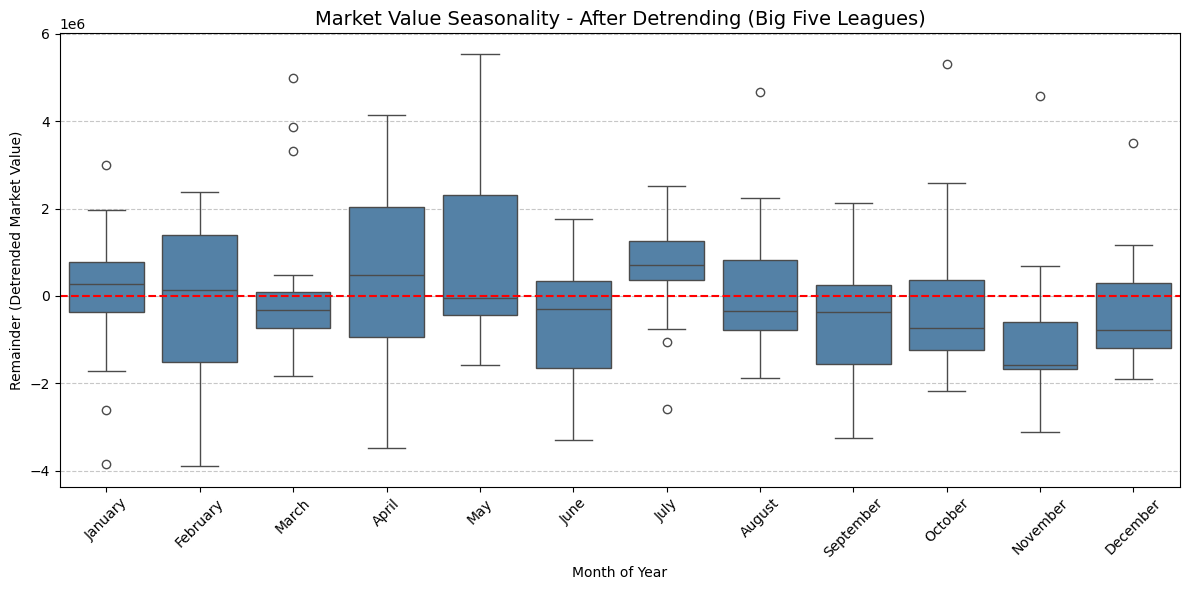

In [10]:
#Big Five Leagues

#Estimate trend using 31-period Centered Moving Average
big_five_train['trend'] = big_five_train['market_value_capped'].rolling(window=13, center=True).mean()

#Decompose (Calculate Remainder/Detrended Data)
big_five_train['remainder'] = big_five_train['market_value_capped'] - big_five_train['trend']

#Check for Seasonality (Aggregating by Month)
big_five_train['month'] = big_five_train.index.month_name()

#Plot boxplot 
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=big_five_train.dropna(), 
    x='month', 
    y='remainder', 
    color='steelblue',
    order=['January', 'February', 'March', 'April', 'May', 'June', 
           'July', 'August', 'September', 'October', 'November', 'December']
)

plt.axhline(0, color='red', linestyle='--')
plt.title("Market Value Seasonality - After Detrending (Big Five Leagues)", fontsize=14)
plt.xlabel("Month of Year")
plt.ylabel("Remainder (Detrended Market Value)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

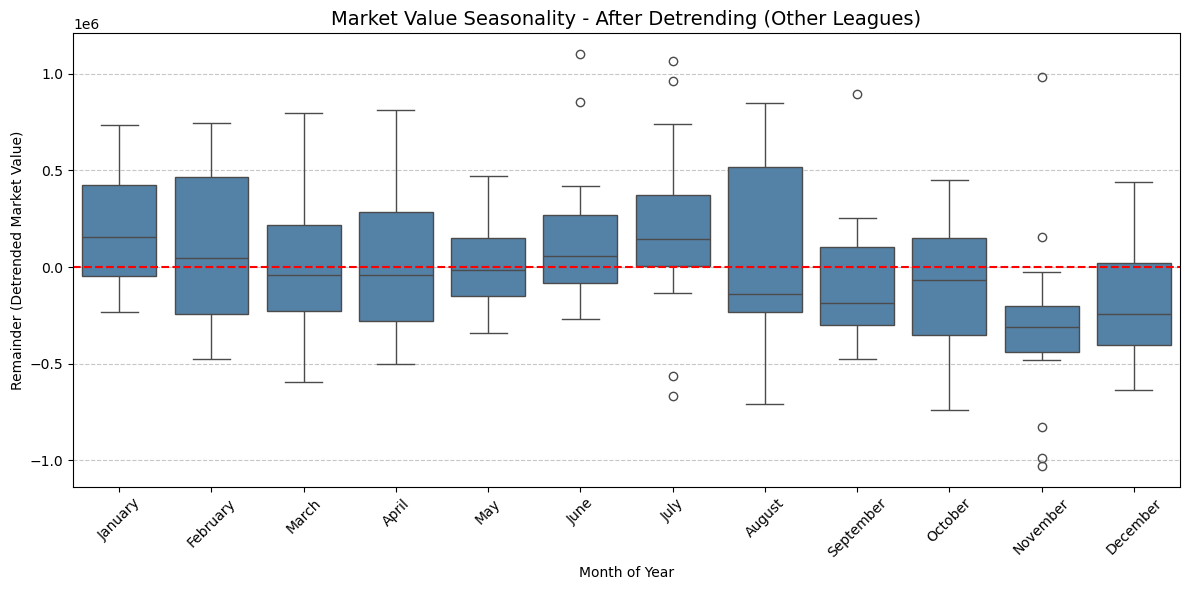

In [11]:
#Other Leagues

#Estimate trend using 31-period Centered Moving Average
other_train['trend'] = other_train['market_value_capped'].rolling(window=13, center=True).mean()

#Decompose (Calculate Remainder/Detrended Data)
other_train['remainder'] = other_train['market_value_capped'] - other_train['trend']

#Check for Seasonality (Aggregating by Month)
other_train['month'] = other_train.index.month_name()

#Plot boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(
    data=other_train.dropna(), 
    x='month', 
    y='remainder', 
    color='steelblue',
    order=['January', 'February', 'March', 'April', 'May', 'June', 
           'July', 'August', 'September', 'October', 'November', 'December']
)

plt.axhline(0, color='red', linestyle='--')
plt.title("Market Value Seasonality - After Detrending (Other Leagues)", fontsize=14)
plt.xlabel("Month of Year")
plt.ylabel("Remainder (Detrended Market Value)")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#### Check for Variance Stationarity

Necessary step for ARIMA modeling

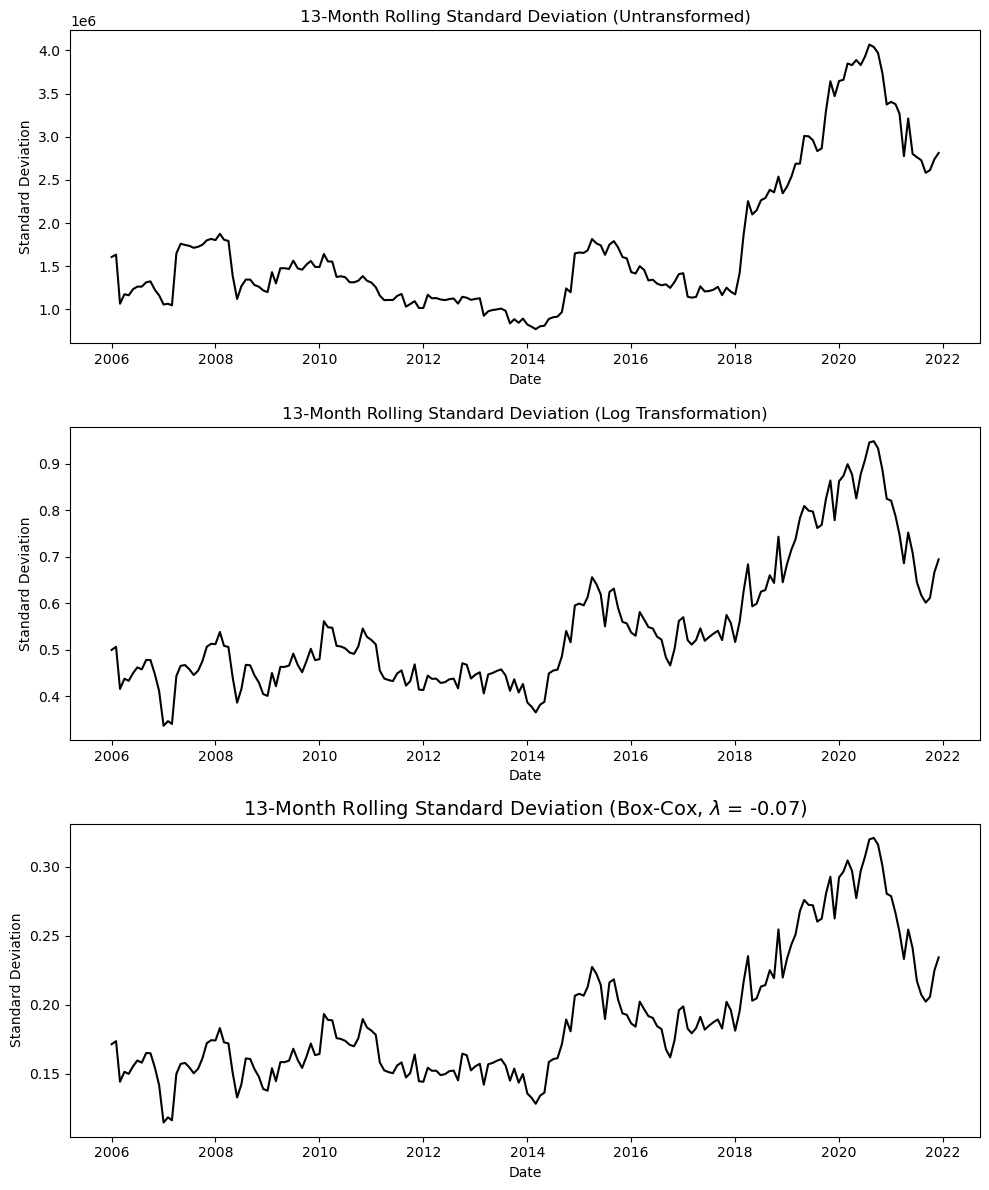

In [12]:
#Big Five Leagues

#Transformations on market value
big_five_train['market_value_log'] = np.log1p(big_five_train['market_value_capped'])
big_five_train['market_value_boxcox'], lmbda = boxcox(big_five_train['market_value_capped'])

#Calculate rolling standard deviation (to check for variance stationarity)
big_five_train['rolling_sd'] = big_five_train['market_value_capped'].rolling(window=13).std()
big_five_train['rolling_sd_log'] = big_five_train['market_value_log'].rolling(window=13).std()
big_five_train['rolling_sd_boxcox'] = big_five_train['market_value_boxcox'].rolling(window=13).std()


#Plot and compare results
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

#Original data
sns.lineplot(ax=axes[0], data=big_five_train, x=big_five_train.index, y='rolling_sd', color='black')

axes[0].set_title("13-Month Rolling Standard Deviation (Untransformed)")
axes[0].set_ylabel("Standard Deviation")
axes[0].set_xlabel("Date")

#Log transformed
sns.lineplot(ax=axes[1], data=big_five_train, x=big_five_train.index, y='rolling_sd_log', color='black')

axes[1].set_title("13-Month Rolling Standard Deviation (Log Transformation)")
axes[1].set_ylabel("Standard Deviation")
axes[1].set_xlabel("Date")

#Box-Cox transformation
sns.lineplot(ax=axes[2], data=big_five_train, x=big_five_train.index, y='rolling_sd_boxcox', color='black')

axes[2].set_title(f"13-Month Rolling Standard Deviation (Box-Cox, $\lambda$ = {lmbda:.2f})", fontsize=14)
axes[2].set_ylabel("Standard Deviation")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.show()

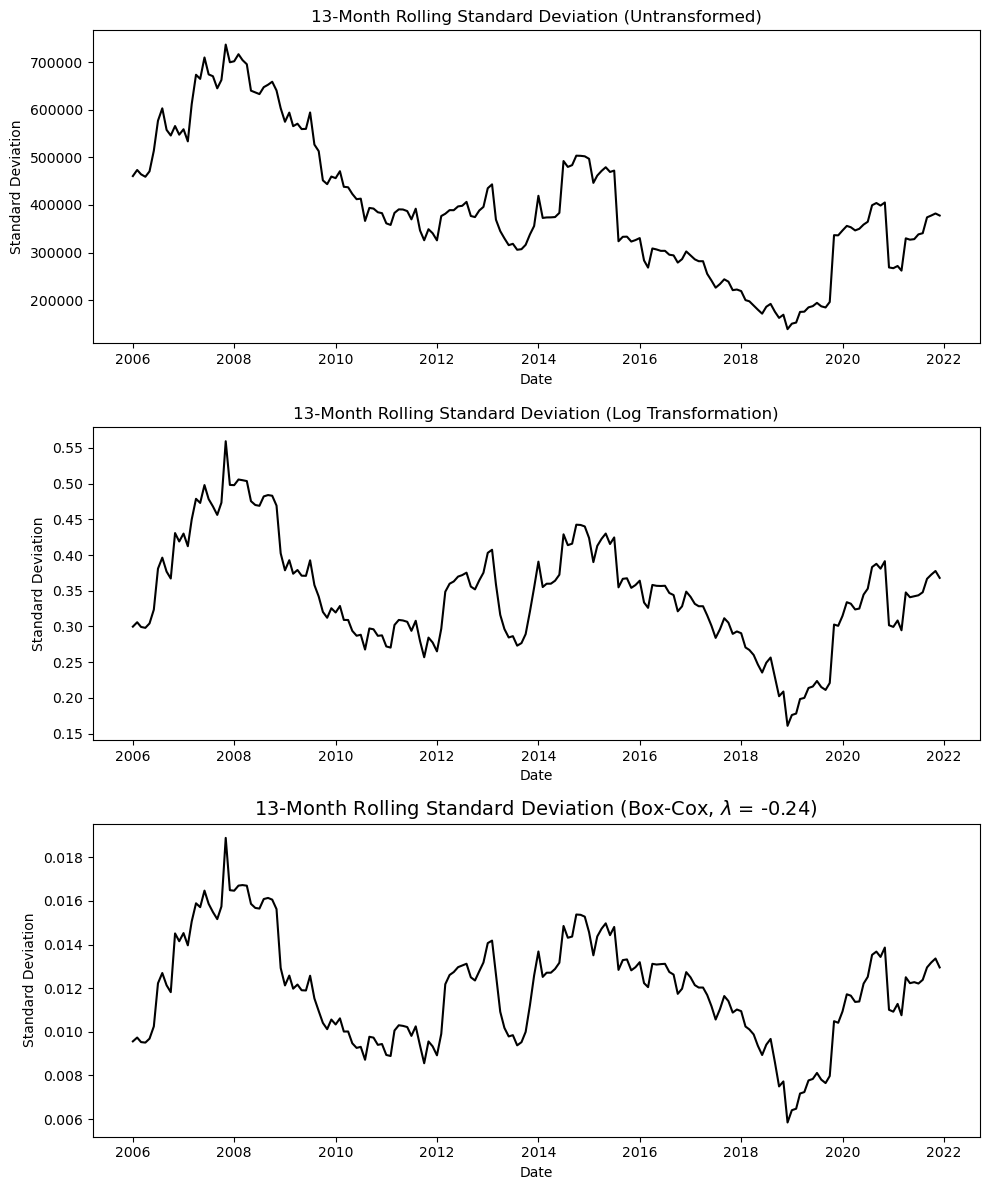

In [13]:
#Other Leagues

#Transformations on market value
other_train['market_value_log'] = np.log1p(other_train['market_value_capped'])
other_train['market_value_boxcox'], lmbda = boxcox(other_train['market_value_capped'])

#Calculate rolling standard deviation (to check for variance stationarity)
other_train['rolling_sd'] = other_train['market_value_capped'].rolling(window=13).std()
other_train['rolling_sd_log'] = other_train['market_value_log'].rolling(window=13).std()
other_train['rolling_sd_boxcox'] = other_train['market_value_boxcox'].rolling(window=13).std()


#Plot and compare results
fig, axes = plt.subplots(3, 1, figsize=(10, 12))

#Original data
sns.lineplot(ax=axes[0], data=other_train, x=other_train.index, y='rolling_sd', color='black')

axes[0].set_title("13-Month Rolling Standard Deviation (Untransformed)")
axes[0].set_ylabel("Standard Deviation")
axes[0].set_xlabel("Date")

#Log transformed
sns.lineplot(ax=axes[1], data=other_train, x=other_train.index, y='rolling_sd_log', color='black')

axes[1].set_title("13-Month Rolling Standard Deviation (Log Transformation)")
axes[1].set_ylabel("Standard Deviation")
axes[1].set_xlabel("Date")

#Box-Cox transformation
sns.lineplot(ax=axes[2], data=other_train, x=other_train.index, y='rolling_sd_boxcox', color='black')

axes[2].set_title(f"13-Month Rolling Standard Deviation (Box-Cox, $\lambda$ = {lmbda:.2f})", fontsize=14)
axes[2].set_ylabel("Standard Deviation")
axes[2].set_xlabel("Date")

plt.tight_layout()
plt.show()

#### Check for Mean Stationarity

Done on log transformed data

In [14]:
# First-order differencing
big_five_train['diff_value'] = big_five_train.loc[:, 'market_value_log'].diff()
statistic, p_value, n_lags, critical_values = kpss(big_five_train['diff_value'].dropna())

kpss_result = kpss(big_five_train['diff_value'].dropna(), regression='c')
print(f"\nKPSS Test Big Five Leagues (H0: Series is stationary)")
print(f"  Statistic: {kpss_result[0]:.4f}")
print(f"  p-value: {kpss_result[1]:.4f}")
print(f"  Result: {'Non-Stationary' if kpss_result[1] < 0.05 else 'Stationary'}")

# First-order differencing
other_train['diff_value'] = other_train.loc[:, 'market_value_log'].diff()
statistic, p_value, n_lags, critical_values = kpss(other_train['diff_value'].dropna())

kpss_result = kpss(other_train['diff_value'].dropna(), regression='c')
print(f"\nKPSS Test Other Leagues (H0: Series is stationary)")
print(f"  Statistic: {kpss_result[0]:.4f}")
print(f"  p-value: {kpss_result[1]:.4f}")
print(f"  Result: {'Non-Stationary' if kpss_result[1] < 0.05 else 'Stationary'}")


KPSS Test Big Five Leagues (H0: Series is stationary)
  Statistic: 0.1549
  p-value: 0.1000
  Result: Stationary

KPSS Test Other Leagues (H0: Series is stationary)
  Statistic: 0.0822
  p-value: 0.1000
  Result: Stationary


C:\Users\megan\AppData\Local\Temp\ipykernel_7316\463487156.py:3: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, n_lags, critical_values = kpss(big_five_train['diff_value'].dropna())
C:\Users\megan\AppData\Local\Temp\ipykernel_7316\463487156.py:5: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_result = kpss(big_five_train['diff_value'].dropna(), regression='c')
C:\Users\megan\AppData\Local\Temp\ipykernel_7316\463487156.py:13: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  statistic, p_value, n_lags, critical_values = kpss(other_train['diff_value'].dropna())
C:\Users\megan\AppData\Local\Temp\ipykernel_73

#### ACF/PACF plots

Significant lags at t=12 may indicate some annual seasonality

No dampening in ACF means not autoregressive; maybe MA(1)? 

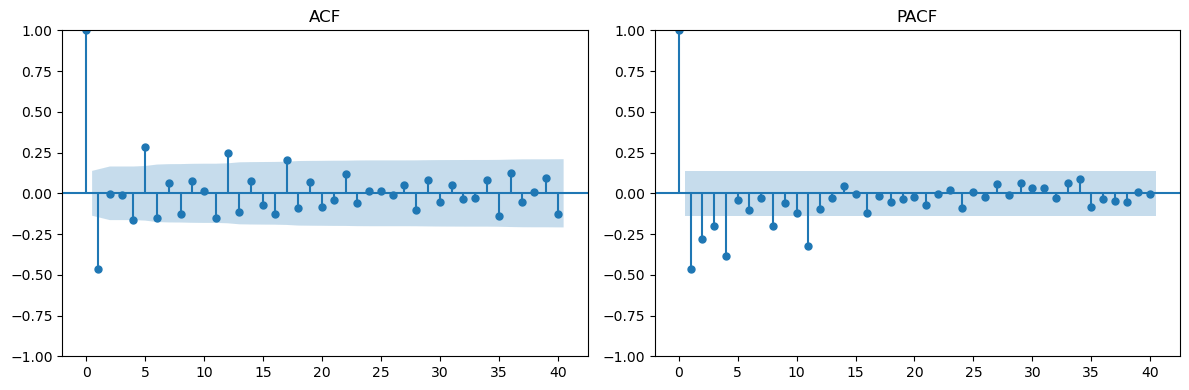

In [15]:
#Big five leagues

#Combined ACF/PACF plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(big_five_train['diff_value'].dropna(), lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF')
plot_pacf(big_five_train['diff_value'].dropna(), lags=40, ax=axes[1], alpha=0.05)
axes[1].set_title('PACF')
plt.tight_layout()
plt.show()



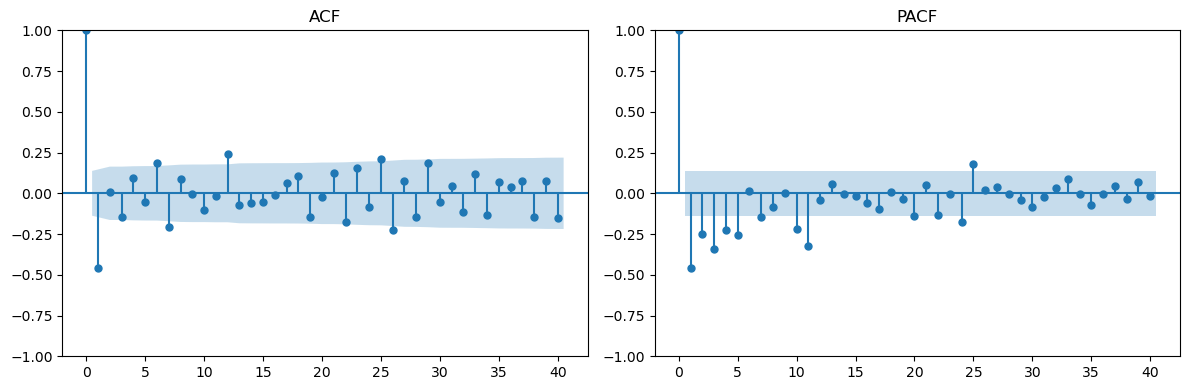

In [16]:
#Other leagues

#Combined ACF/PACF plot
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf(other_train['diff_value'].dropna(), lags=40, ax=axes[0], alpha=0.05)
axes[0].set_title('ACF')
plot_pacf(other_train['diff_value'].dropna(), lags=40, ax=axes[1], alpha=0.05)
axes[1].set_title('PACF')
plt.tight_layout()
plt.show()


#### ARIMA Model

In [17]:
#Fit auto-ARIMA model (Big Five leagues)
auto_model_big_five = auto_arima(big_five_train['market_value_log'], stepwise=True, suppress_warnings=True)
auto_fit_big_five = ARIMA(big_five_train['market_value_log'], order=auto_model_big_five.order).fit()

print("Auto ARIMA Results:")
print(f"Best model: ARIMA{auto_model_big_five.order}")
print(f"AIC: {auto_model_big_five.aic():.2f}")
print(f"BIC: {auto_model_big_five.bic():.2f}")
print("\nModel Summary:")
print(auto_model_big_five.summary())

Auto ARIMA Results:
Best model: ARIMA(0, 0, 0)
AIC: 355.12
BIC: 361.76

Model Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  204
Model:                        SARIMAX   Log Likelihood                -175.560
Date:                Wed, 24 Jun 2026   AIC                            355.119
Time:                        18:33:39   BIC                            361.756
Sample:                    01-01-2005   HQIC                           357.804
                         - 12-01-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     14.8441      0.040    369.334      0.000      14.765      14.923
sigma2         0.3274      0.037      8.902 

In [18]:
#Fit auto-ARIMA model (Other leagues)
auto_model_other = auto_arima(other_train['market_value_log'], stepwise=True, suppress_warnings=True)
auto_fit_other = ARIMA(other_train['market_value_log'], order=auto_model_other.order).fit()

print("Auto ARIMA Results:")
print(f"Best model: ARIMA{auto_model_other.order}")
print(f"AIC: {auto_model_other.aic():.2f}")
print(f"BIC: {auto_model_other.bic():.2f}")
print("\nModel Summary:")
print(auto_model_other.summary())

Auto ARIMA Results:
Best model: ARIMA(0, 1, 1)
AIC: 162.19
BIC: 172.13

Model Summary:
                               SARIMAX Results                                
Dep. Variable:                      y   No. Observations:                  204
Model:               SARIMAX(0, 1, 1)   Log Likelihood                 -78.096
Date:                Wed, 24 Jun 2026   AIC                            162.192
Time:                        18:33:40   BIC                            172.131
Sample:                    01-01-2005   HQIC                           166.213
                         - 12-01-2021                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept     -0.0037      0.001     -3.758      0.000      -0.006      -0.002
ma.L1         -0.9694      0.023    -41.448 

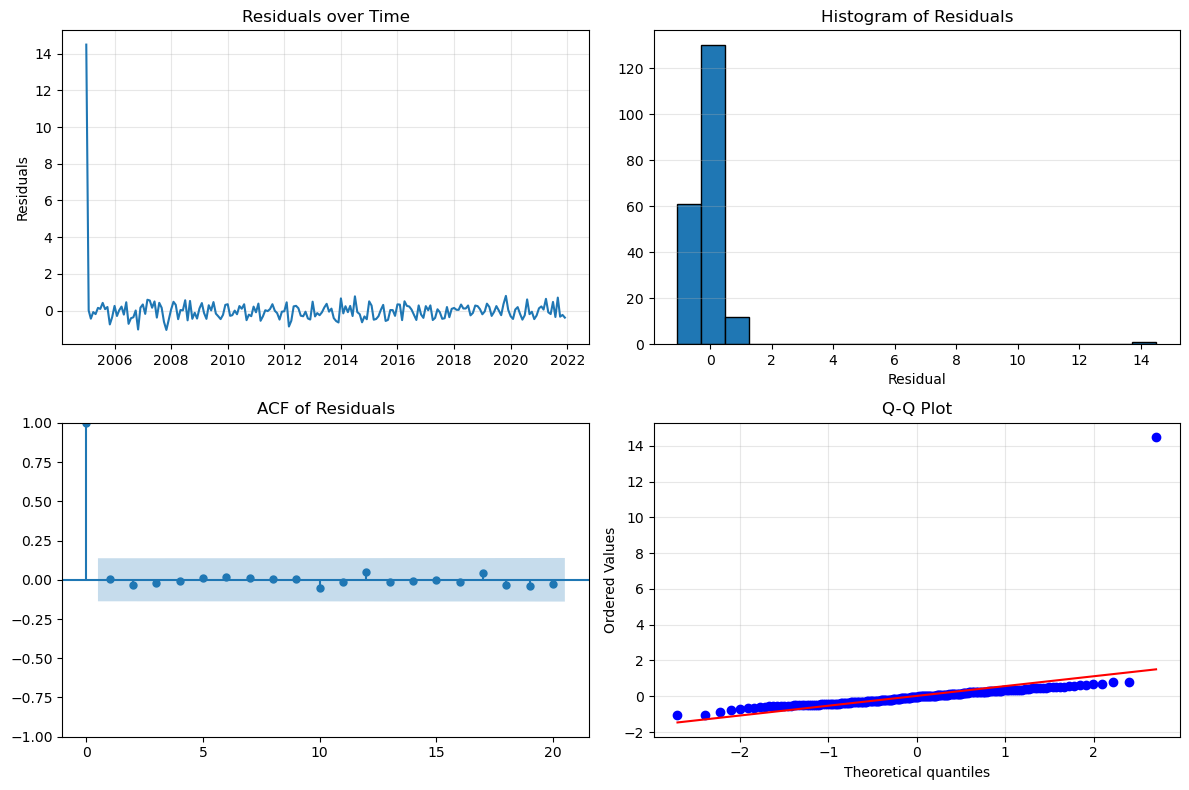


Ljung-Box Test (lag=12):
p-value: 0.9998
Result: Residuals are white noise ✓


In [19]:
# Extract residuals
residuals = auto_fit_other.resid

# Create diagnostic plots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Residuals over time
axes[0, 0].plot(residuals, linewidth=1.5)
axes[0, 0].set_title('Residuals over Time')
axes[0, 0].set_ylabel('Residuals')
axes[0, 0].grid(True, alpha=0.3)

# Histogram
axes[0, 1].hist(residuals, bins=20, edgecolor='black')
axes[0, 1].set_title('Histogram of Residuals')
axes[0, 1].set_xlabel('Residual')
axes[0, 1].grid(True, alpha=0.3, axis='y')

# ACF of residuals
plot_acf(residuals, lags=20, ax=axes[1, 0])
axes[1, 0].set_title('ACF of Residuals')

# Q-Q plot
from scipy import stats
stats.probplot(residuals, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title('Q-Q Plot')
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Ljung-Box test
from statsmodels.stats.diagnostic import acorr_ljungbox

lb_test = acorr_ljungbox(residuals, lags=[12], return_df=True)
print(f"\nLjung-Box Test (lag=12):")
print(f"p-value: {lb_test['lb_pvalue'].values[0]:.4f}")
print(f"Result: {'Residuals are white noise ✓' if lb_test['lb_pvalue'].values[0] > 0.05 else 'Residuals have autocorrelation ✗'}")

#### Generate forecasts

Using both the ARIMA model and historical average 

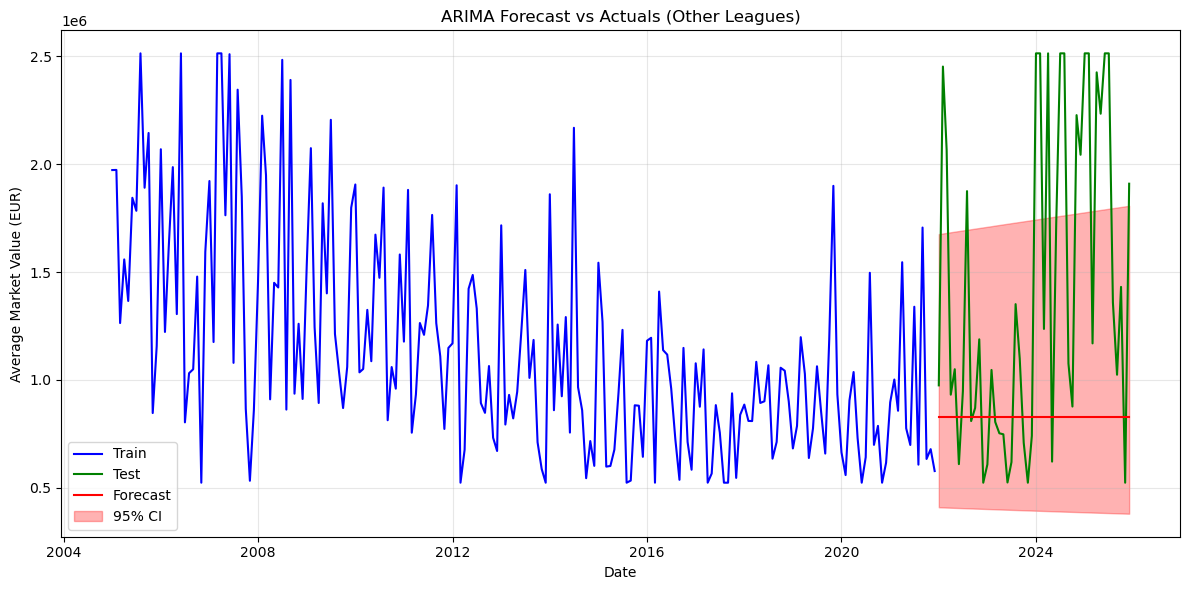

In [20]:
#Use auto-ARIMA model generate forecasts
auto_model_other_log = auto_arima(other_train['market_value_log'], stepwise=True, suppress_warnings=True)
auto_fit_other_log = ARIMA(other_train['market_value_log'], order=auto_model_other_log.order).fit()

#Generate forecasts for the test period
n_periods = len(other_test)
forecast_log = auto_fit_other_log.get_forecast(steps=n_periods)
forecast_ci = forecast_log.conf_int()

#Convert forecasts back to original scale
forecast = np.expm1(forecast_log.predicted_mean)
forecast_lower = np.expm1(forecast_ci['lower market_value_log'])
forecast_upper = np.expm1(forecast_ci['upper market_value_log'])

#Plot forecasts vs. actuals
plt.figure(figsize=(12, 6))
plt.plot(other_train.index, other_train['market_value_capped'], label='Train', color='blue')
plt.plot(other_test.index, other_test['market_value_capped'], label='Test', color='green')
plt.plot(other_test.index, forecast, label='Forecast', color='red')
plt.fill_between(other_test.index, forecast_lower, forecast_upper, color='red', alpha=0.3, label='95% CI')
plt.title('ARIMA Forecast vs Actuals (Other Leagues)')
plt.xlabel('Date')
plt.ylabel('Average Market Value (EUR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



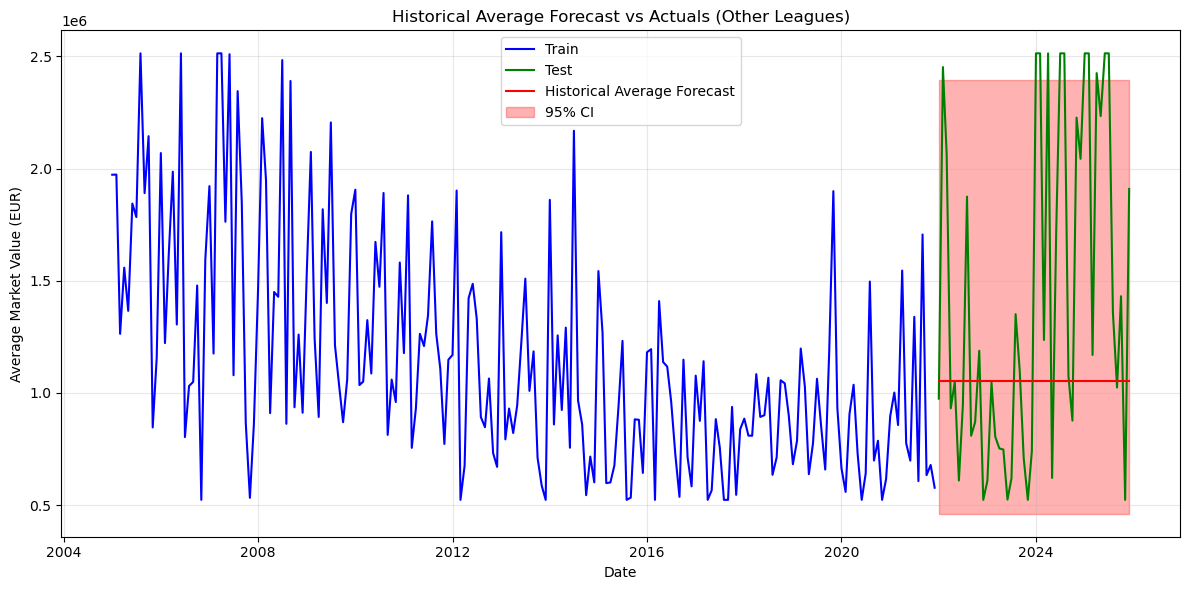

In [21]:
#Fit the NaiveForecaster on log data
naive_model = NaiveForecaster(strategy="mean")
naive_model.fit(other_train['market_value_log'])

#Generate forecasts for the test period
n_periods = len(other_test)
fh = np.arange(1, n_periods + 1)

#Get the point forecast
forecast_log = naive_model.predict(fh=fh)

#Get the prediction intervals
forecast_ci = naive_model.predict_interval(fh=fh, coverage=0.95)

#Convert forecasts back to original scale
forecast_ha = np.expm1(forecast_log)

lower_col = forecast_ci.columns[0] 
upper_col = forecast_ci.columns[1] 

forecast_lower = np.expm1(forecast_ci[lower_col])
forecast_upper = np.expm1(forecast_ci[upper_col])

#Plot forecasts vs. actuals
plt.figure(figsize=(12, 6))
plt.plot(other_train.index, other_train['market_value_capped'], label='Train', color='blue')
plt.plot(other_test.index, other_test['market_value_capped'], label='Test', color='green')
plt.plot(other_test.index, forecast_ha, label='Historical Average Forecast', color='red')
plt.fill_between(other_test.index, forecast_lower, forecast_upper, color='red', alpha=0.3, label='95% CI')
plt.title('Historical Average Forecast vs Actuals (Other Leagues)')
plt.xlabel('Date')
plt.ylabel('Average Market Value (EUR)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Compare Model Results

Historical average forecast performs better than the ARIMA, based on RMSE

In [22]:
#Compute RMSE for ARIMA model and historical average baseline and compare
from sklearn.metrics import mean_squared_error

# ARIMA RMSE
arima_rmse = np.sqrt(mean_squared_error(other_test['market_value_capped'], forecast))
print(f"ARIMA RMSE: {arima_rmse:.2f}")

# Historical Average RMSE
naive_rmse = np.sqrt(mean_squared_error(other_test['market_value_capped'], forecast_ha))
print(f"Historical Average RMSE: {naive_rmse:.2f}")


ARIMA RMSE: 945534.37
Historical Average RMSE: 823928.15


#### Final Plots

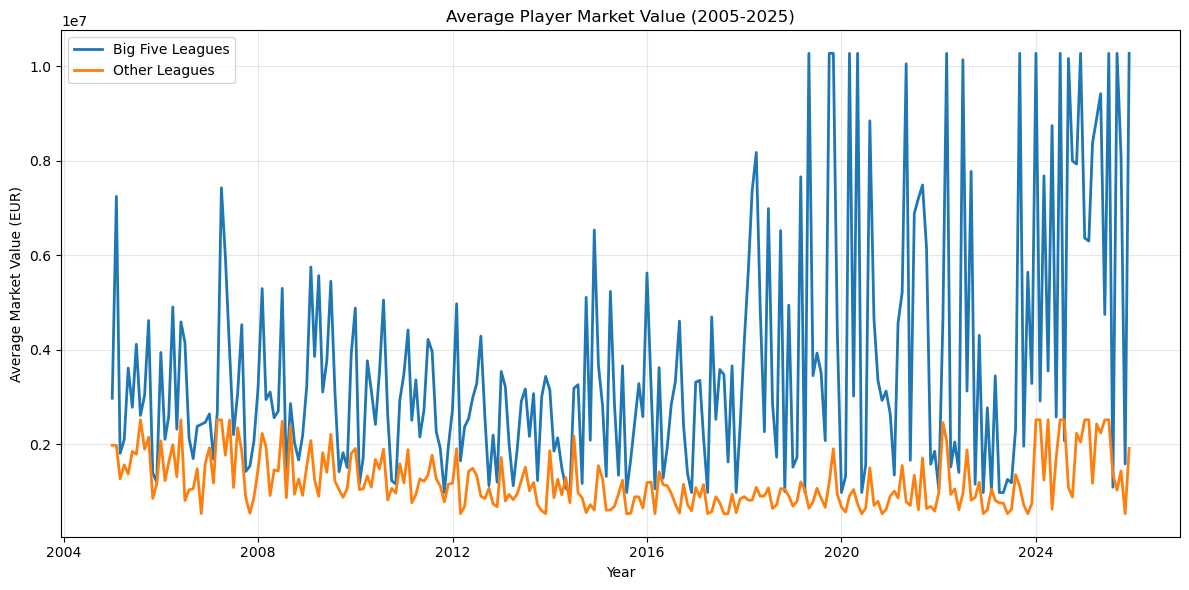

In [23]:
#Create clean time series plot for presentation
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(big_five_clean.index, big_five_clean['market_value_capped'], 
        label='Big Five Leagues', linewidth=2)

ax.plot(other_clean.index, other_clean['market_value_capped'], 
        label='Other Leagues', linewidth=2)

ax.set_title('Average Player Market Value (2005-2025)')
ax.set_xlabel('Year')
ax.set_ylabel('Average Market Value (EUR)')
ax.grid(True, alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

C:\Users\megan\AppData\Local\Temp\ipykernel_7316\561238182.py:20: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  forecast_dates = pd.date_range(start=last_date, periods=fh_steps + 1, freq='M')[1:]


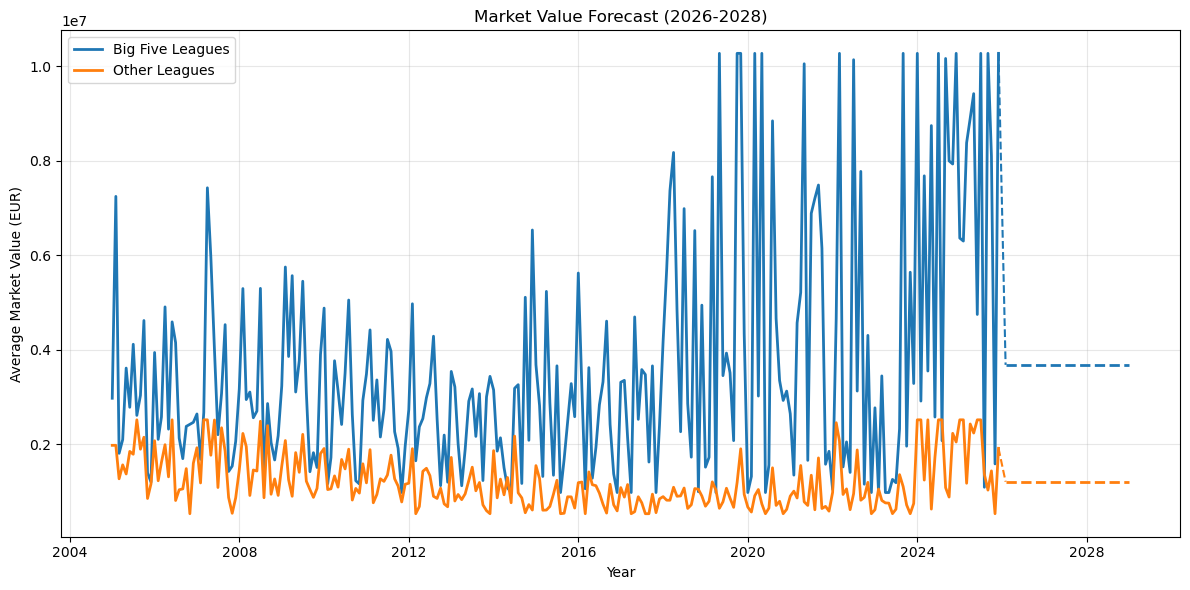

In [24]:
#Create clean forecast plot for presentation

forecaster_other = NaiveForecaster(strategy="mean")
forecaster_big_five = NaiveForecaster(strategy="mean")

# Fit and Predict
forecaster_other.fit(other_clean['market_value_capped'])
fh = np.arange(1, 37) # Predict the next 3 years
predictions_other = forecaster_other.predict(fh)

forecaster_big_five.fit(big_five_clean['market_value_capped'])
predictions_big_five = forecaster_big_five.predict(fh)


#Ensure the Forecast Horizon and Dates Match
fh_steps = 36 
last_date = other_clean.index[-1]

# Generate 36 future dates 
forecast_dates = pd.date_range(start=last_date, periods=fh_steps + 1, freq='M')[1:]

fig, ax = plt.subplots(figsize=(12, 6))

#Plot Historical Data
ax.plot(big_five_clean.index, big_five_clean['market_value_capped'], 
        label='Big Five Leagues', color='#1f77b4', linewidth=2)

ax.plot(other_clean.index, other_clean['market_value_capped'], 
         label='Other Leagues', color='#ff7f0e', linewidth=2)

#Plot the Naive Forecast
ax.plot(forecast_dates, predictions_big_five,
         linestyle='--', color='#1f77b4', linewidth=2)

ax.plot(forecast_dates, predictions_other,
         linestyle='--', color='#ff7f0e', linewidth=2)

#Connect the History to the Forecast
#This bridges the gap between the last real data point and the first prediction
ax.plot([big_five_clean.index[-1], forecast_dates[0]], 
         [big_five_clean['market_value_capped'].iloc[-1], predictions_big_five.iloc[0]], 
         color='#1f77b4', linestyle='--')

ax.plot([other_clean.index[-1], forecast_dates[0]], 
         [other_clean['market_value_capped'].iloc[-1], predictions_other.iloc[0]], 
         color='#ff7f0e', linestyle='--')

ax.set_title('Market Value Forecast (2026-2028)')
ax.set_xlabel('Year')
ax.set_ylabel('Average Market Value (EUR)')
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Format Data for Dashboard


In [25]:
# Convert predictions to a DataFrame and name the column to match your training data
other_predictions_df = predictions_other.to_frame()
other_predictions_df.columns = ['market_value_capped']

# Assign the forecast dates we created earlier as the index
other_predictions_df.index = forecast_dates

other_clean.loc[:, 'type'] = 'Actual'
other_predictions_df.loc[:, 'type'] = 'Forecast'

# Combine (Append) them vertically
full_series_other_final = pd.concat([other_clean[['market_value_capped']], other_predictions_df])


#Repeat process for Big Five Leagues
big_five_predictions_df = predictions_big_five.to_frame()
big_five_predictions_df.columns = ['market_value_capped']
big_five_predictions_df.index = forecast_dates
big_five_predictions_df.loc[:, 'type'] = 'Forecast'

big_five_clean.loc[:, 'type'] = 'Actual'
big_five_predictions_df.loc[:, 'type'] = 'Forecast'

full_series_big_five_final = pd.concat([big_five_clean[['market_value_capped']], big_five_predictions_df])

#print(full_series_other_final.tail(20))

In [26]:
#Save data to CSV
full_series_big_five_final.to_csv('full_series_big_five_final.csv')
full_series_other_final.to_csv('full_series_other_final.csv')